### Imports and some basic color setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
import warnings
warnings.filterwarnings('ignore')

In [3]:
# This whole aesthtic section is AI generated, propmpted it (Claude sonnet) to make the plot look fire and dark themed and it did a prety good job.
plt.rcParams.update({
    'figure.dpi': 130,
    'figure.facecolor': '#0f0f0f',
    'axes.facecolor': '#1a1a1a',
    'axes.edgecolor': '#444',
    'axes.labelcolor': '#e0e0e0',
    'axes.titlecolor': '#ffffff',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.color': '#aaa',
    'ytick.color': '#aaa',
    'text.color': '#e0e0e0',
    'grid.color': '#2e2e2e',
    'grid.linestyle': '--',
    'legend.facecolor': '#1a1a1a',
    'legend.edgecolor': '#444',
    'font.family': 'DejaVu Sans',
})

PALETTE   = ['#4fc3f7', '#ff8a65', '#a5d6a7', '#ce93d8']
FIRE_COLORS = {'Low':'#4fc3f7', 'Moderate':'#ffcc02', 'High':'#ff8a65', 'Extreme':'#e53935'}
TARGET_ORDER = ['Low', 'Moderate', 'High', 'Extreme']

In [9]:
# Data Loading 
train_df=pd.read_csv('wildfire_cls_train_full.csv')
# We can import the test set later when we are ready to clear it for data leakage and formatting it similar to the train set after data preprocessing and feature engineering.

print(train_df.head(10))
print('\n')
print(f'Shape of the training data: {train_df.shape}')

   latitude  longitude    acq_date  acq_time  year  month  season daynight  \
0  -22.1967   -61.5275  2024-08-12      1838  2024    NaN  Winter        D   
1   64.2205   -53.4116  2024-07-11       424  2024    7.0  Summer        N   
2   38.6810     9.5739  2024-06-18       546  2024    6.0  Summer        N   
3   68.1959   -90.3475  2024-08-26      2240  2024    8.0  Summer        N   
4    0.6527   118.6227  2025-08-09      2301  2025    8.0  Summer        N   
5   33.4589    71.9806  2025-11-01      1536  2025   11.0  Autumn        D   
6   28.4294    63.9391  2024-05-30       530  2024    5.0  Spring        N   
7  -29.2148   122.2033  2024-02-19      1840  2024    NaN  Summer        D   
8   25.4646  -136.8306  2024-09-09      1823  2024    9.0  Autumn        D   
9  -17.6045   123.0066  2024-02-27      2205  2024    2.0  Summer        N   

           region     country      fire_type  satellite instrument  \
0   South_America        Peru  Deforestation  Suomi-NPP      VIIRS   
1

In [10]:
# always easy to just do .info()
print(train_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   latitude        4340 non-null   float64
 1   longitude       4340 non-null   float64
 2   acq_date        4340 non-null   object 
 3   acq_time        4340 non-null   int64  
 4   year            4340 non-null   int64  
 5   month           3924 non-null   float64
 6   season          4340 non-null   object 
 7   daynight        4340 non-null   object 
 8   region          4340 non-null   object 
 9   country         4340 non-null   object 
 10  fire_type       4340 non-null   object 
 11  satellite       4340 non-null   object 
 12  instrument      4340 non-null   object 
 13  brightness_k    4013 non-null   float64
 14  confidence      4340 non-null   object 
 15  temp_max_c      4340 non-null   float64
 16  wind_max_kmh    4133 non-null   float64
 17  precip_mm       4340 non-null   f

 Upon quick overview we csn check that there is lot of missing values in some of the features like "month", "brightness_k" etc., and they are all of varying data types. lets first check how the values in the feature "acq_date" are coz often its the one feature that has most issues

 

In [13]:
print(train_df['acq_date'])

0       2024-08-12
1       2024-07-11
2       2024-06-18
3       2024-08-26
4       2025-08-09
           ...    
4335    2024-06-19
4336    2025-04-17
4337    2024-09-13
4338    2024-12-05
4339    2025-05-09
Name: acq_date, Length: 4340, dtype: object


In [14]:
print(train_df['month'])

0        NaN
1        7.0
2        6.0
3        8.0
4        8.0
        ... 
4335     6.0
4336     4.0
4337     9.0
4338    12.0
4339     5.0
Name: month, Length: 4340, dtype: float64


In [15]:
# its seems like the "month" feature was feature engineered from the "acq_date" feature with so many missing values.

Since the data for wildfires is mostly acquired from datasets, there is a good chacne many of the features are correlated for example "pressure",could be correlated to "humidity" and the whole reason those features are missing could be beacuase of failure of the sensor. anyway before we start dealing with missing values and feature engineering and data preperation le's see the data summary and some important overview like the percentage of missing rows per feature

In [17]:
overview =pd.DataFrame({
  'dtype':        train_df.dtypes,
    'nulls':        train_df.isnull().sum(),
    'null_%':       (train_df.isnull().mean()*100).round(2),
    'n_unique':     train_df.nunique(),
    'sample':       train_df.iloc[0]
})

print(overview)

                  dtype  nulls  null_%  n_unique         sample
latitude        float64      0    0.00      4329       -22.1967
longitude       float64      0    0.00      4335       -61.5275
acq_date         object      0    0.00       709     2024-08-12
acq_time          int64      0    0.00      1375           1838
year              int64      0    0.00         2           2024
month           float64    416    9.59        12            NaN
season           object      0    0.00         4         Winter
daynight         object      0    0.00         2              D
region           object      0    0.00         7  South_America
country          object      0    0.00        35           Peru
fire_type        object      0    0.00        10  Deforestation
satellite        object      0    0.00         4      Suomi-NPP
instrument       object      0    0.00         2          VIIRS
brightness_k    float64    327    7.53      2949         360.26
confidence       object      0    0.00  

In [18]:
print("NUMERICAL SUMMARY")
train_df.describe().T.style.background_gradient(cmap='YlOrRd', axis=1)

NUMERICAL SUMMARY


,count,mean,std,min,25%,50%,75%,max
latitude,4340.000000,9.821703,24.321271,-42.988300,-8.611625,10.268500,29.011025,69.930900
longitude,4340.000000,29.430626,78.842700,-167.990600,-40.980600,34.833700,95.166775,153.754900
acq_time,4340.000000,1177.046774,683.844117,0.000000,602.000000,1208.000000,1752.000000,2359.000000
year,4340.000000,2024.501843,0.500054,2024.000000,2024.000000,2025.000000,2025.000000,2025.000000
month,3924.000000,7.240316,2.791615,1.000000,5.000000,8.000000,9.000000,12.000000
brightness_k,4013.000000,336.677742,18.539217,290.000000,324.860000,335.530000,346.990000,503.710000
temp_max_c,4340.000000,35.082627,5.821218,17.700000,31.000000,35.100000,39.125000,54.100000
wind_max_kmh,4133.000000,17.508033,17.051980,0.000000,5.100000,12.400000,24.000000,130.700000
precip_mm,4340.000000,2.597111,3.062512,0.000000,0.600000,1.540000,3.370000,23.690000
humidity_pct,4340.000000,37.924378,18.731153,5.000000,24.200000,36.200000,50.500000,95.000000


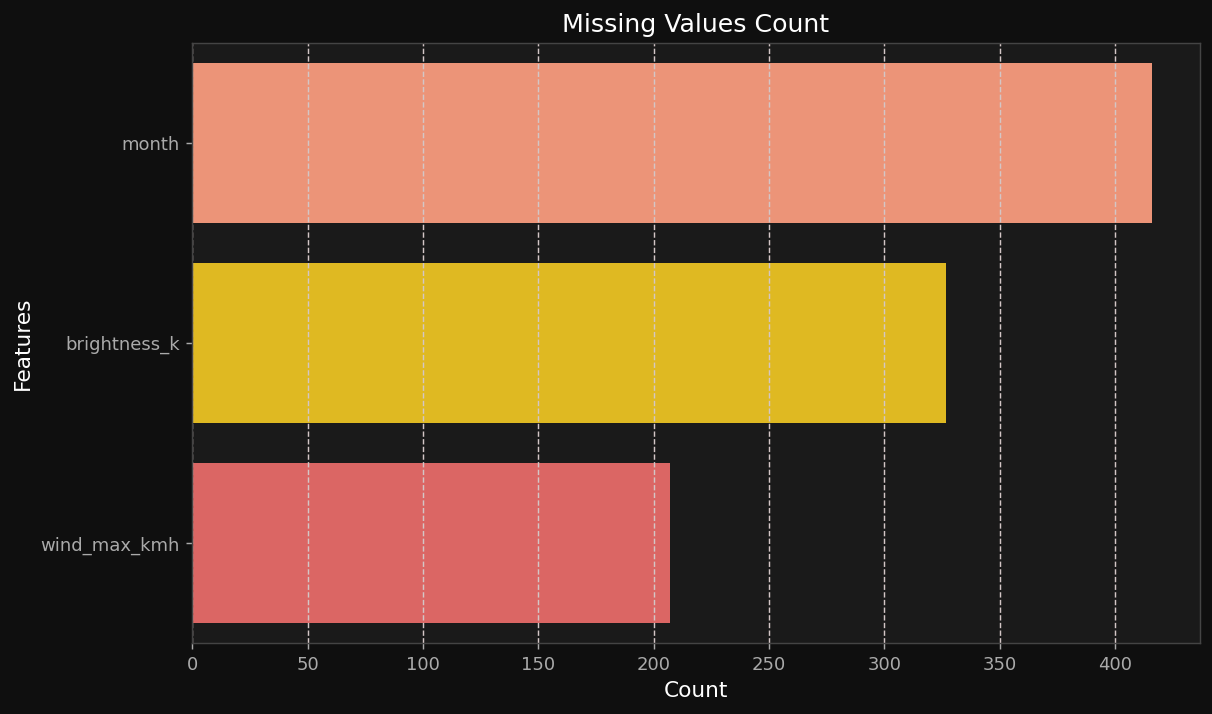

<Figure size 832x624 with 0 Axes>

In [26]:
missing_values =train_df.isnull().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x=missing_values.values, y=missing_values.index, palette=['#ff8a65', '#ffcc02', '#ef5350'])
plt.title('Missing Values Count', fontsize=14, color='white')
plt.xlabel('Count', fontsize=12, color='white')
plt.ylabel('Features', fontsize=12, color='white')
plt.grid(axis='x', color="#d3c6c6", linestyle='--')
plt.style.background_color="#F0E4E400"
plt.show()
plt.tight_layout()

## 2. Checking correleation bwtween missing value features

earlier we talked about how the some features could be correlated and if they are indeed correlated then dealing with missing values could involve considering all the corelated features together and not individually, this is true for imputation or some feature selection. 

In [27]:
miss_combo = train_df[['month','brightness_k','wind_max_kmh']].isnull()
print(miss_combo.corr().round(3))

              month  brightness_k  wind_max_kmh
month         1.000        -0.019         0.019
brightness_k -0.019         1.000         0.039
wind_max_kmh  0.019         0.039         1.000


Seems like they are indeed not corelated 

## 3. Imputation rationale 

### 3.1 imputing the unreliable month feature.

for this we could simply extract the month variable from "acq_date" and replace all the values in "month" feature with the extracted value

In [29]:
# always better to work on a duplicated dataset than original,
df=train_df.copy()
# we saw that the feature "acq_date" is a Object data type and to extract the "month", "year" and "day" features from it we hav eto convert it inot a datatie vatiable.

df['acq_date'] =pd.to_datetime(df['acq_date'],errors='coerce')
# now we can just replace the whole month feature with the onth extracted from "acq_date"ArithmeticError
df['month'] =df['acq_date'].dt.month

In [30]:
df['month'].isnull().sum()

np.int64(0)

In [31]:
df['month'].dtype

dtype('int32')

In [32]:
# You know what if there are missing value it could also be true that the "year" and "day" feature could also be wrong ! so lets just replace those as welll with the extracted values from 'acq_date"

df['year']=df['acq_date'].dt.year
df['day']=df['acq_date'].dt.day



In [33]:
df.columns

Index(['latitude', 'longitude', 'acq_date', 'acq_time', 'year', 'month',
       'season', 'daynight', 'region', 'country', 'fire_type', 'satellite',
       'instrument', 'brightness_k', 'confidence', 'temp_max_c',
       'wind_max_kmh', 'precip_mm', 'humidity_pct', 'fire_intensity', 'day'],
      dtype='object')

Alright from what's dpne so far we extracted new features from 'acq_date" atleast some of them , since we are going for Decision Trees and SVM, they cant really learn from complex temporal features like "axq_date" and "acq_time", so we could also extract features from "acq_time" , lets do that after we finis with imputing the missing values for rest of the features 

reference : https://towardsdatascience.com/cyclical-encoding-an-alternative-to-one-hot-encoding-for-time-series-features-4db46248ebba/

In [35]:
df['date_dayofweek'] = df['acq_date'].dt.dayofweek
df['date_dayofyear'] = df['acq_date'].dt.dayofyear

df['acq_time_str'] = df['acq_time'].astype(str).str.zfill(4)
df['hour']   = df['acq_time_str'].str[:2].astype(int)
df['minute'] = df['acq_time_str'].str[2:].astype(int)

In [37]:
df.columns.tolist()

['latitude',
 'longitude',
 'acq_date',
 'acq_time',
 'year',
 'month',
 'season',
 'daynight',
 'region',
 'country',
 'fire_type',
 'satellite',
 'instrument',
 'brightness_k',
 'confidence',
 'temp_max_c',
 'wind_max_kmh',
 'precip_mm',
 'humidity_pct',
 'fire_intensity',
 'day',
 'date_dayofweek',
 'date_dayofyear',
 'acq_time_str',
 'hour',
 'minute']

In [39]:
# since we extracted some of the columns we can delete the original ones to avoid leaking
df.drop(columns=['acq_date','acq_time','acq_time_str'], inplace=True)

In [40]:
df.columns.tolist()

['latitude',
 'longitude',
 'year',
 'month',
 'season',
 'daynight',
 'region',
 'country',
 'fire_type',
 'satellite',
 'instrument',
 'brightness_k',
 'confidence',
 'temp_max_c',
 'wind_max_kmh',
 'precip_mm',
 'humidity_pct',
 'fire_intensity',
 'day',
 'date_dayofweek',
 'date_dayofyear',
 'hour',
 'minute']

In [41]:
df.head()

,latitude,longitude,year,month,season,daynight,region,country,fire_type,satellite,...,temp_max_c,wind_max_kmh,precip_mm,humidity_pct,fire_intensity,day,date_dayofweek,date_dayofyear,hour,minute
0,-22.1967,-61.5275,2024,8,Winter,D,South_America,Peru,Deforestation,Suomi-NPP,...,40.6,39.0,0.11,17.1,Extreme,12,0,225,18,38
1,64.2205,-53.4116,2024,7,Summer,N,North_America,Canada,Forest,Suomi-NPP,...,38.9,NaN,0.06,13.2,Low,11,3,193,4,24
2,38.6810,9.5739,2024,6,Summer,N,Mediterranean,Spain,Wildfire,AQUA,...,36.9,30.1,0.19,35.2,High,18,1,170,5,46
3,68.1959,-90.3475,2024,8,Summer,N,North_America,USA,Forest,TERRA,...,43.8,17.7,0.98,32.8,Extreme,26,0,239,22,40
4,0.6527,118.6227,2025,8,Summer,N,Southeast_Asia,Malaysia,Peatland,TERRA,...,34.8,1.0,0.18,83.2,Moderate,9,5,221,23,1


## 3.2 Imputation for brightness_k

For this i think we could either use regular imputation like median mean and etc or i believe there is a strong corelation between "fire_intensity" and "brightness_k' since, if the intensity is high brightness has to be high, to prove that lets check the corelation and some plots


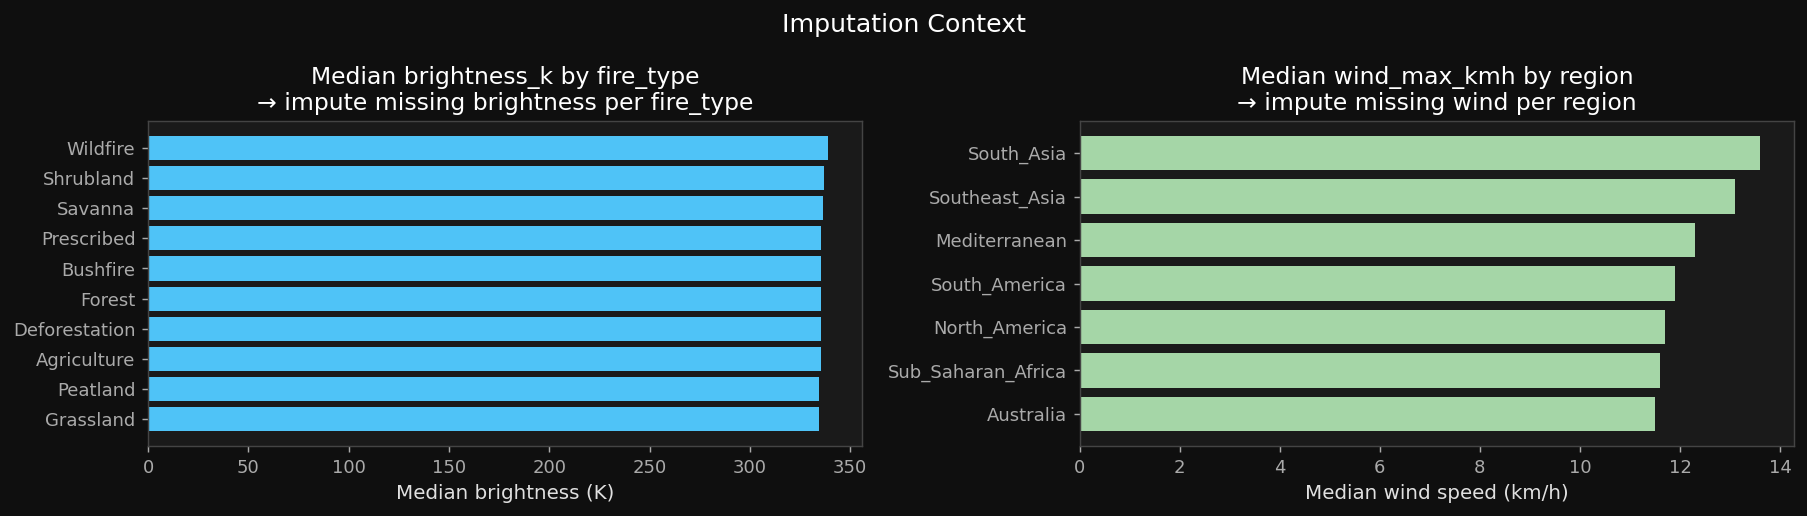

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Imputation Context', fontsize=14, color='white')

# brightness medians per fire_type
bmed = df.groupby('fire_type')['brightness_k'].median().sort_values()
axes[0].barh(bmed.index, bmed.values, color='#4fc3f7')
axes[0].set_title('Median brightness_k by fire_type\n→ impute missing brightness per fire_type')
axes[0].set_xlabel('Median brightness (K)')

# wind medians per region
wmed = df.groupby('region')['wind_max_kmh'].median().sort_values()
axes[1].barh(wmed.index, wmed.values, color='#a5d6a7')
axes[1].set_title('Median wind_max_kmh by region\n→ impute missing wind per region')
axes[1].set_xlabel('Median wind speed (km/h)')

plt.tight_layout()
plt.show()

So the main idea here is instead of using the median of the feature we group them into different "fire_types" so that we know we are categorizing thr typical range of brightness, for exaplme a house fire could be way smaller than bushfire and if we ctake common median we might end u overrshooting the brightness value of a row which has the "fire_type " feature as "housefire", TLDR, not sure if housefire exists in dataset, just an example.

in the next imputation function im just using .get(....,fallback) just in case if nomedian exists then it just takes the over all median of that particular feature instead of the group medians.

In [44]:
brightness_median = df.groupby('fire_type')['brightness_k'].median().to_dict()
wind_medians      = df.groupby('region')['wind_max_kmh'].median().to_dict()

def impute(df, brightness_median, wind_medians):
    df = df.copy()
    df['brightness_k'] = df.groupby('fire_type')['brightness_k'].transform(
        lambda x: x.fillna(brightness_median.get(x.name, df['brightness_k'].median())))
    df['brightness_k'].fillna(df['brightness_k'].median(), inplace=True)
    df['wind_max_kmh'] = df.groupby('region')['wind_max_kmh'].transform(
        lambda x: x.fillna(wind_medians.get(x.name, df['wind_max_kmh'].median())))
    df['wind_max_kmh'].fillna(df['wind_max_kmh'].median(), inplace=True)
    return df

df   = impute(df, brightness_median, wind_medians)
# test = impute(test, brightness_median, wind_medians)


## 4 Target Variable Distribution 

Let's understand how the target variable is distributed, usually we can do this in the last satge of data prep but i guess some steps are interchangable 

This is a vital step because a certain class could be highly over represented compared to others an dthat could create some training bias, as such the model would be heavily skewed, we caould simple check the distribution with some basic graphs

Text(0.5, 1.0, 'Class Proportions')

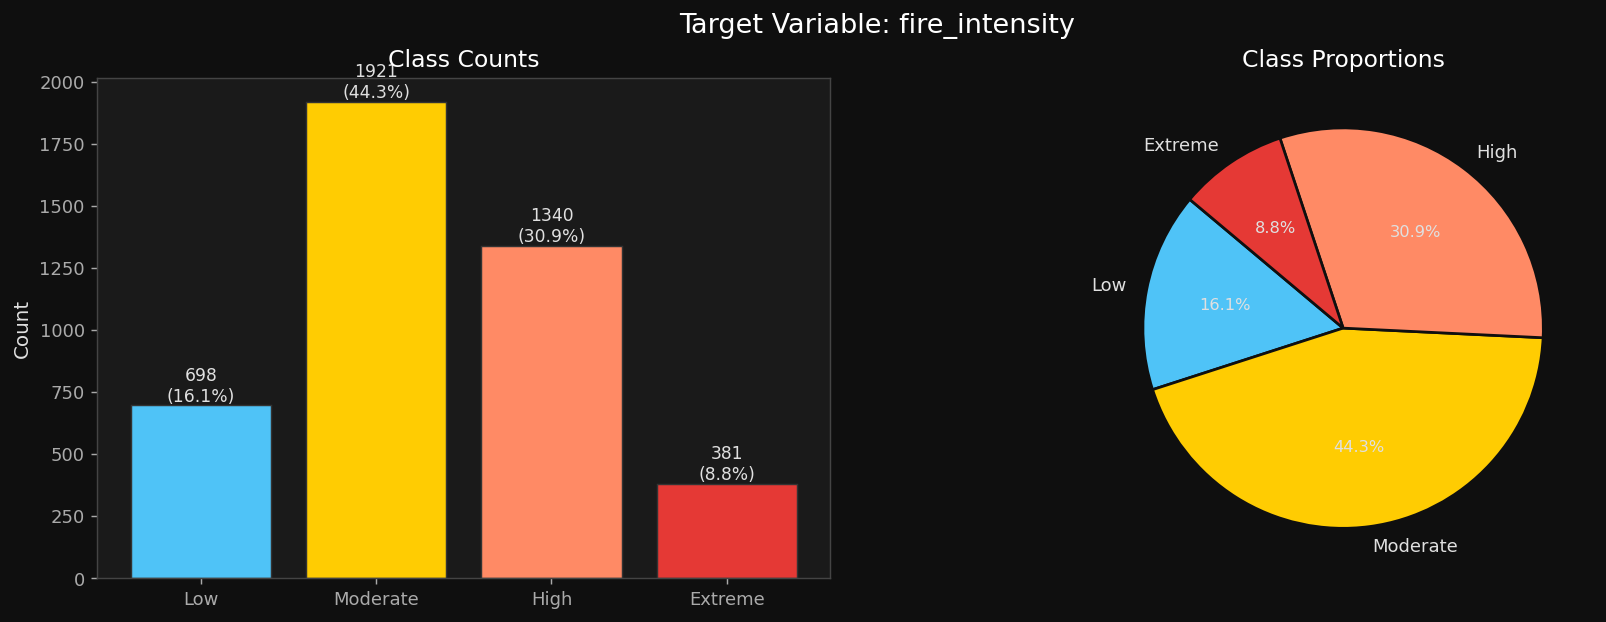

In [ ]:
TARGET_ORDER = ['Low', 'Moderate', 'High', 'Extreme']
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Target Variable: fire_intensity', fontsize=15, color='white')

counts  = df['fire_intensity'].value_counts().reindex(TARGET_ORDER)
pcts    = counts / len(df) * 100
colors  = [FIRE_COLORS[c] for c in TARGET_ORDER]

# A bar for a simple count and percentage 
axes[0].bar(TARGET_ORDER, counts.values, color=colors, edgecolor='#333', linewidth=0.8)
for i, (v, p) in enumerate(zip(counts.values, pcts.values)):
    axes[0].text(i, v + 15, f'{v}\n({p:.1f}%)', ha='center', fontsize=9.5)
axes[0].set_title('Class Counts')
axes[0].set_ylabel('Count')

# Impactful pieeee
wedges, texts, autotexts = axes[1].pie(
    counts.values, labels=TARGET_ORDER, colors=colors,
    autopct='%1.1f%%', startangle=140,
    wedgeprops=dict(edgecolor='#0f0f0f', linewidth=1.5))
for at in autotexts: at.set_fontsize(9)
axes[1].set_title('Class Proportions')

So Extreme fires are representing roughly 8.8% of the samples, which is underrepresentation, we cann account this during the data modelling phase. 

## 5 Neumerical feature distribution and target variable check 

We know correlation basically gives linear relationship between two variable, but often the variables are not linearly corelated, but somtimes they could be non linear, multimodel or overlapping this can be captured effectively with KDE and histograms. And also they clearly show calss seperatio , which is an important infromation we need, which would have been lost with linear correlation. 

So we are checking if these features show different patterns for different fire intensities 




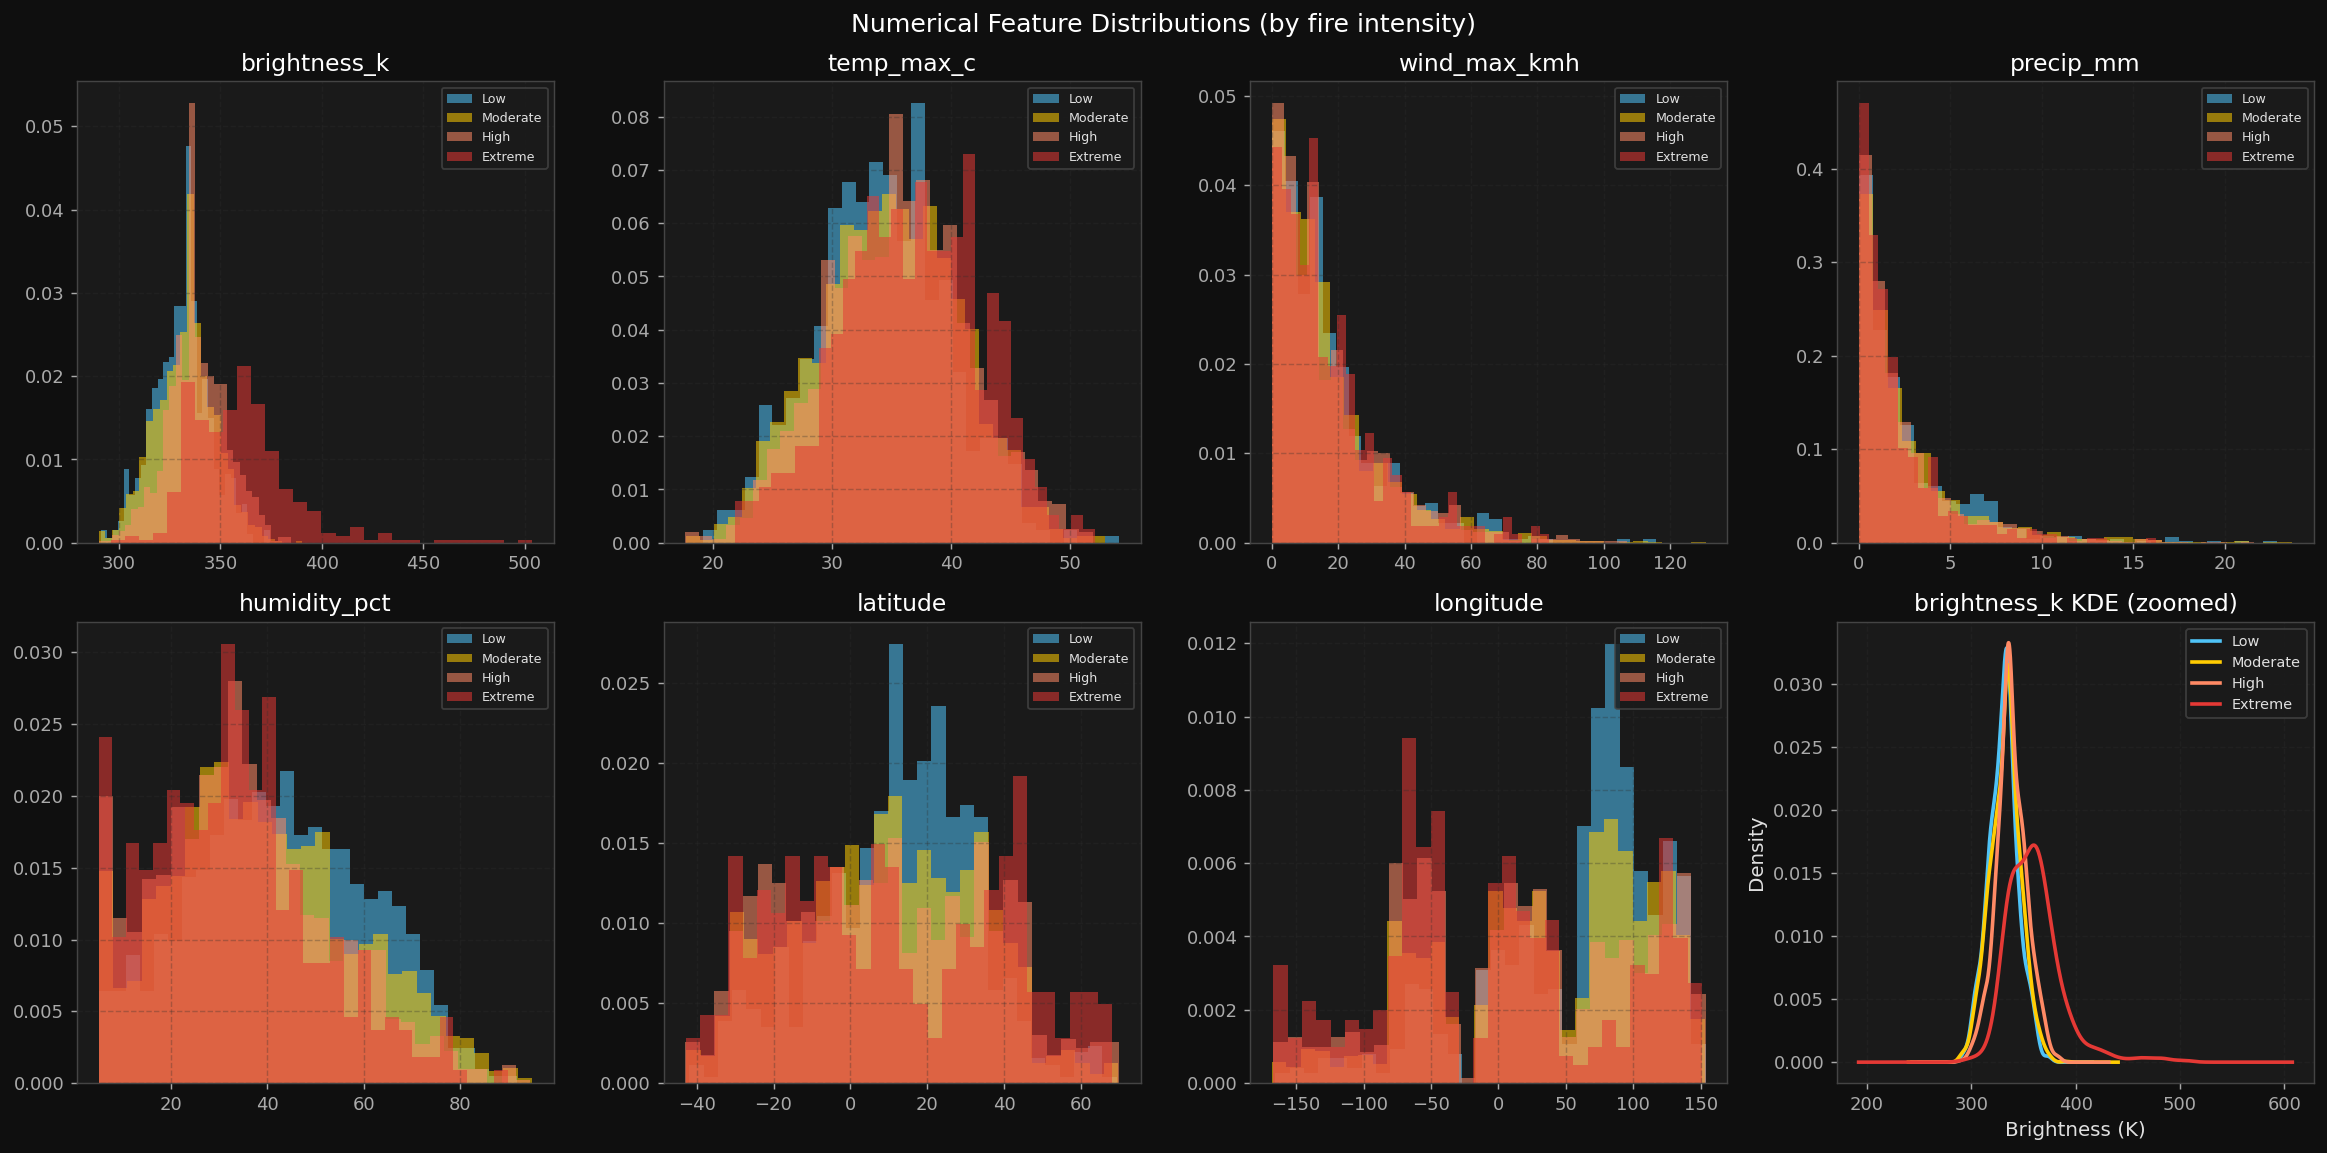

In [50]:
num_cols = ['brightness_k', 'temp_max_c', 'wind_max_kmh',
            'precip_mm', 'humidity_pct', 'latitude', 'longitude']

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle('Numerical Feature Distributions (by fire intensity)', fontsize=14, color='white')
axes = axes.flatten()

for i, col in enumerate(num_cols):
    for cls in TARGET_ORDER:
        subset = df[df['fire_intensity'] == cls][col].dropna()
        axes[i].hist(subset, bins=30, alpha=0.55, color=FIRE_COLORS[cls],
                     label=cls, density=True)
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].legend(fontsize=7, loc='upper right')
    axes[i].grid(True, alpha=0.3)

# Most discriminative panel 
ax = axes[7]
for cls in TARGET_ORDER:
    subset = df[df['fire_intensity'] == cls]['brightness_k'].dropna()
    subset.plot.kde(ax=ax, color=FIRE_COLORS[cls], label=cls, linewidth=2)
ax.set_title('brightness_k KDE (zoomed)')
ax.set_xlabel('Brightness (K)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

The most intresting one here that i belive will conribute most to the training is the lattitude and longitude, you can see there are multiple peaks, which reprresents fire clusters in specific geographical regions!!!! That's a clear patttern, also seems like different intensity clusters seems to occur in different regions, that's a clear indication of an pattern, 

for example, a rainforest region could still have fires but could be low intensity, which is clearly showed by the "blue" distribution, similar case to the red distribution which is kind of extreme 

## 6 Categorical feature analysis 

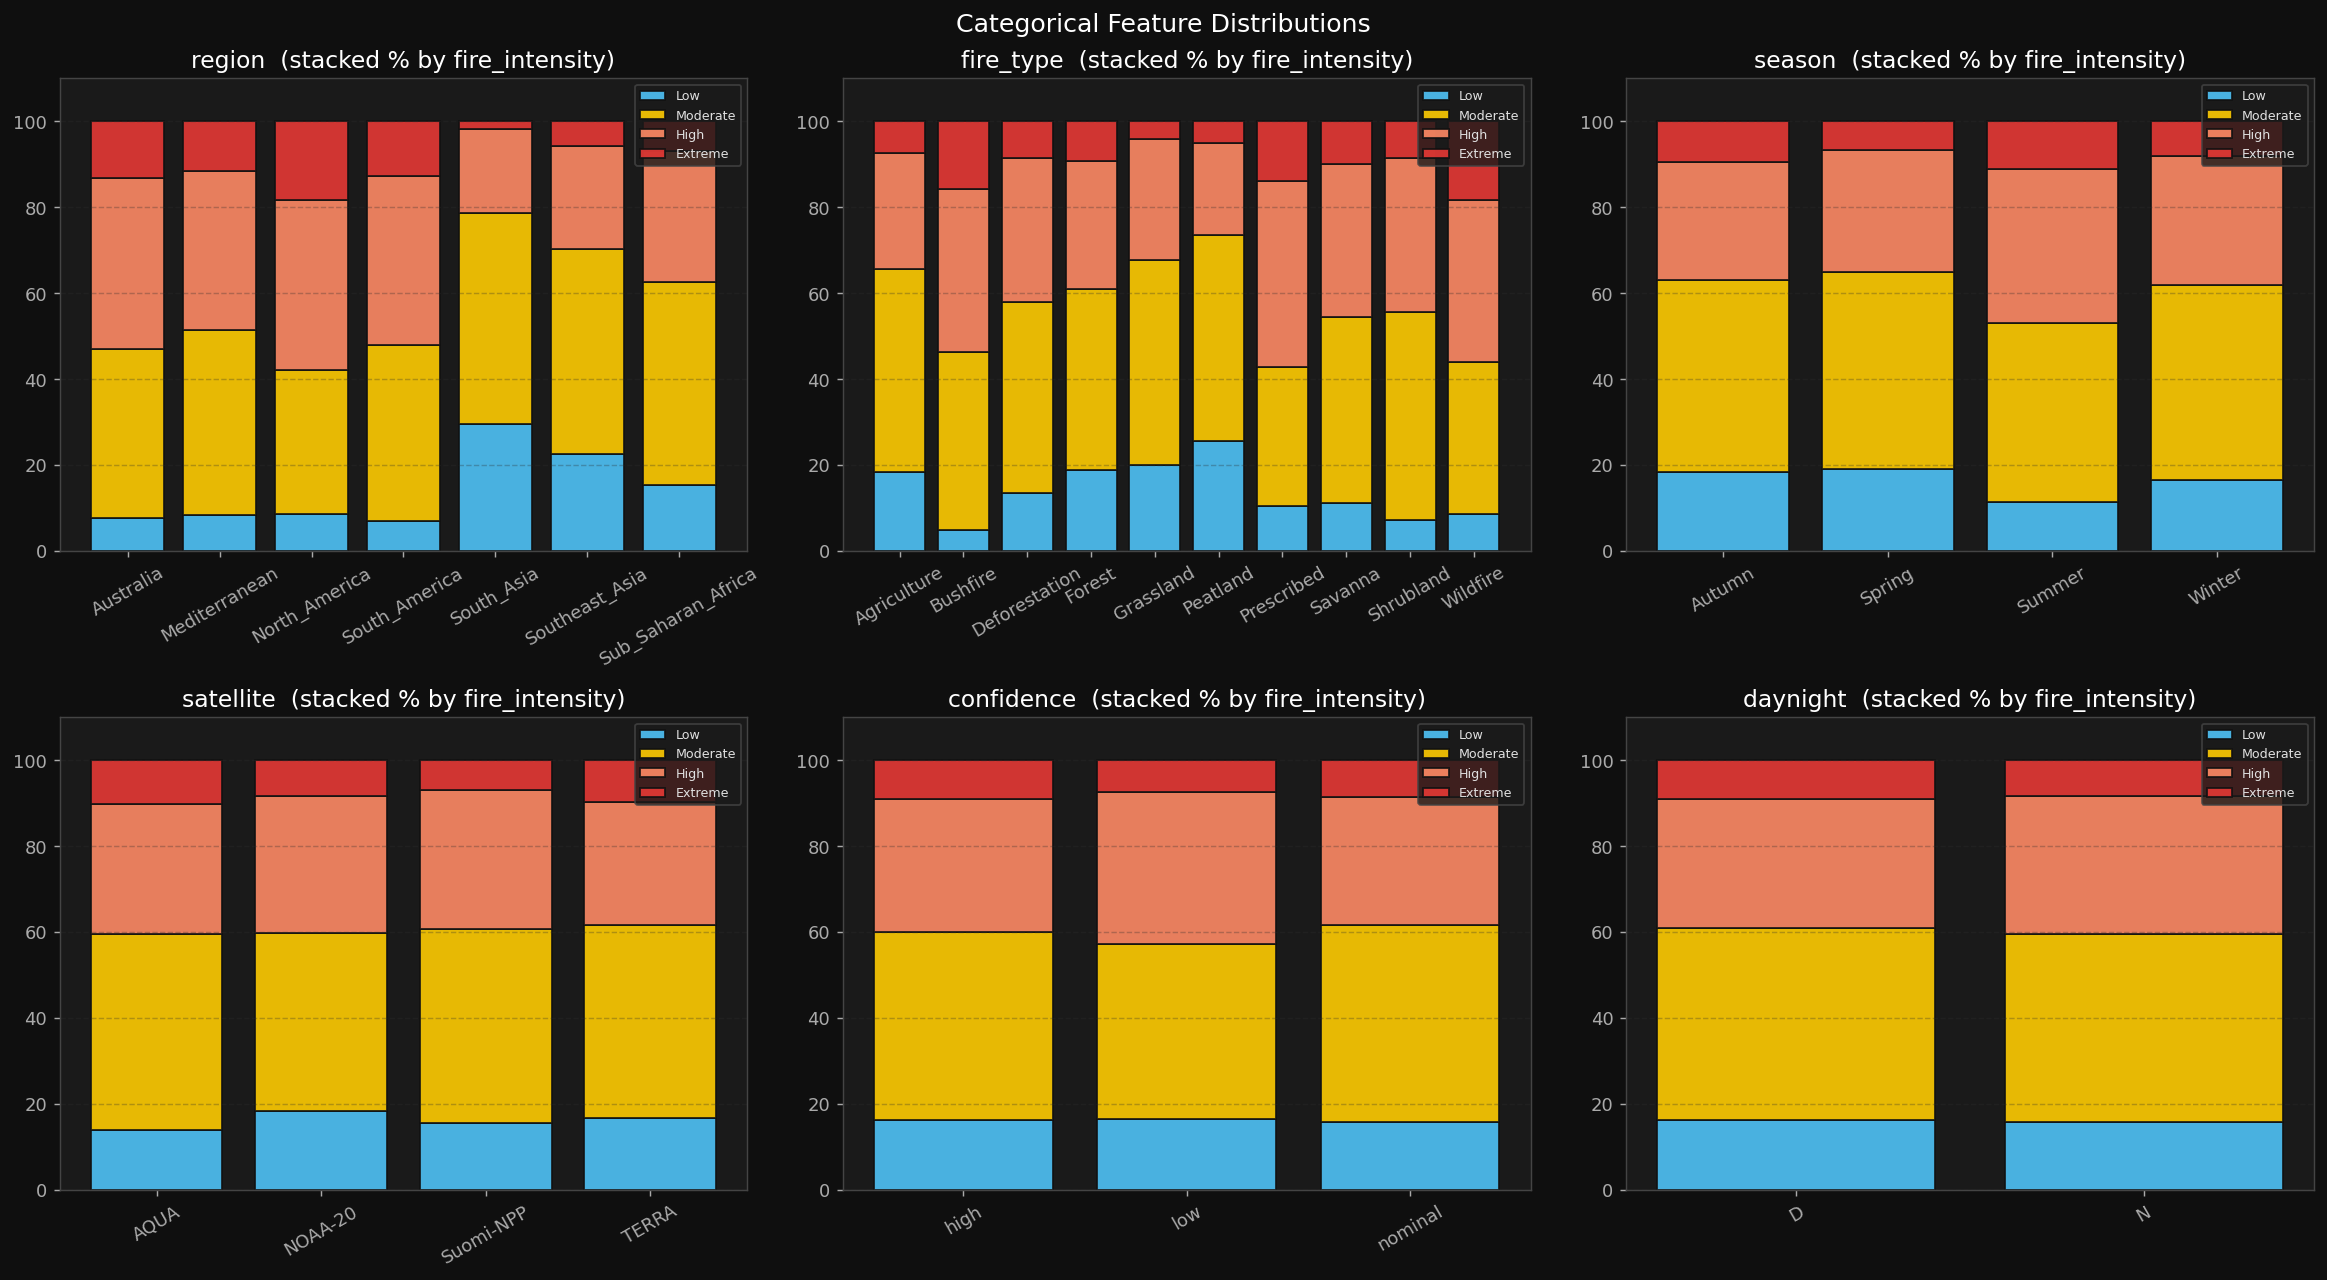

In [51]:
cat_cols = ['region', 'fire_type', 'season', 'satellite', 'confidence', 'daynight']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Categorical Feature Distributions', fontsize=14, color='white')
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ct = df.groupby([col, 'fire_intensity']).size().unstack(fill_value=0)
    ct = ct.reindex(columns=TARGET_ORDER, fill_value=0)
    ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

    bottom = np.zeros(len(ct_pct))
    for cls in TARGET_ORDER:
        axes[i].bar(ct_pct.index, ct_pct[cls], bottom=bottom,
                    color=FIRE_COLORS[cls], label=cls, alpha=0.9, edgecolor='#111')
        bottom += ct_pct[cls].values

    axes[i].set_title(f'{col}  (stacked % by fire_intensity)')
    axes[i].set_ylim(0, 110)
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].legend(fontsize=7, loc='upper right')
    axes[i].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

This graph basically tells "daynight " is not really doing what its expected to do, we would think the intensity is low during night but the feature isnt really showing that so i believe we could dropit, also all the "Satellites" are doing the same job so it's an obvious drop.

the main dilema is with the "confidence", i believe there could be some data leakeage between strong and weak categoreis but not sure, because "confidence" is basically derived from brightness higher brightness flames are easily detected but that dosent mean lower brightness flames are not easily detected, it's just a confusing feature for me 